## Task 3: Analyze clustering performance and compare transformed feature spaces for improved data interpretation
*Continuous Comparisons on Iris Dataset (comparing Raw 4D vs 2D PCA spaces)*


### Subtask 3.1: K-Means Clustering in the PCA-Reduced Space
**Concept:** Import warnings suppression, and fit a K-Means model on the 2D PCA coordinates generated in Task 1.


In [1]:
#code from task 1,2

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Load Iris dataset
iris = load_iris()

# Extract features and target
X = iris.data
y = iris.target

features = iris.feature_names
feature_names = iris.feature_names
target_names = iris.target_names

# Create main DataFrame
iris_df = pd.DataFrame(
    X,
    columns=features
)

iris_df["species_id"] = y
iris_df["species_name"] = [
    target_names[i] for i in y
]

# Standardize the original 4D feature space
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce 4D features to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC_1", "PC2"]
)

pca_df["species_id"] = y
pca_df["species_name"] = [
    target_names[i] for i in y
]

# Train K-Means on standardized raw 4D feature space
kmeans_raw = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

# Append raw cluster labels to main DataFrame
iris_df["cluster_raw"] = kmeans_raw_labels

print("Task 3 setup completed successfully.")
print("Raw standardized feature dimensions:", X_scaled.shape)
print("PCA reduced feature dimensions:", X_pca.shape)

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Compute external validation metrics for raw feature space
ari_raw = adjusted_rand_score(y, kmeans_raw_labels)
nmi_raw = normalized_mutual_info_score(y, kmeans_raw_labels)

# Compute external validation metrics for PCA-reduced space
ari_pca = adjusted_rand_score(y, kmeans_pca_labels)
nmi_pca = normalized_mutual_info_score(y, kmeans_pca_labels)

Task 3 setup completed successfully.
Raw standardized feature dimensions: (150, 4)
PCA reduced feature dimensions: (150, 2)


In [25]:
import warnings

In [26]:
warnings.filterwarnings("ignore")

In [27]:
from sklearn.cluster import KMeans

In [28]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [29]:
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

In [30]:
iris_df['cluster_pca'] = kmeans_pca_labels
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


### Subtask 3.2: Internal Validation Metrics (Silhouette and Calinski-Harabasz Scores)
**Concept:** Calculate Silhouette and Calinski-Harabasz scores to evaluate the separation and cohesion of clusters in both spaces without true labels.


In [31]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [32]:
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)

In [33]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)

In [34]:
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)

In [35]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

In [36]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")

--- Internal Validation (Unsupervised Quality Metrics) ---
Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90
PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


### Subtask 3.3: Faceted Visual Comparison: K-Means Clusters vs. True Species
**Concept:** Plot a side-by-side comparison of K-Means cluster assignments in the 2D PCA space against actual species labels to check for overlaps.


In [37]:
import matplotlib.pyplot as plt

In [38]:
import seaborn as sns

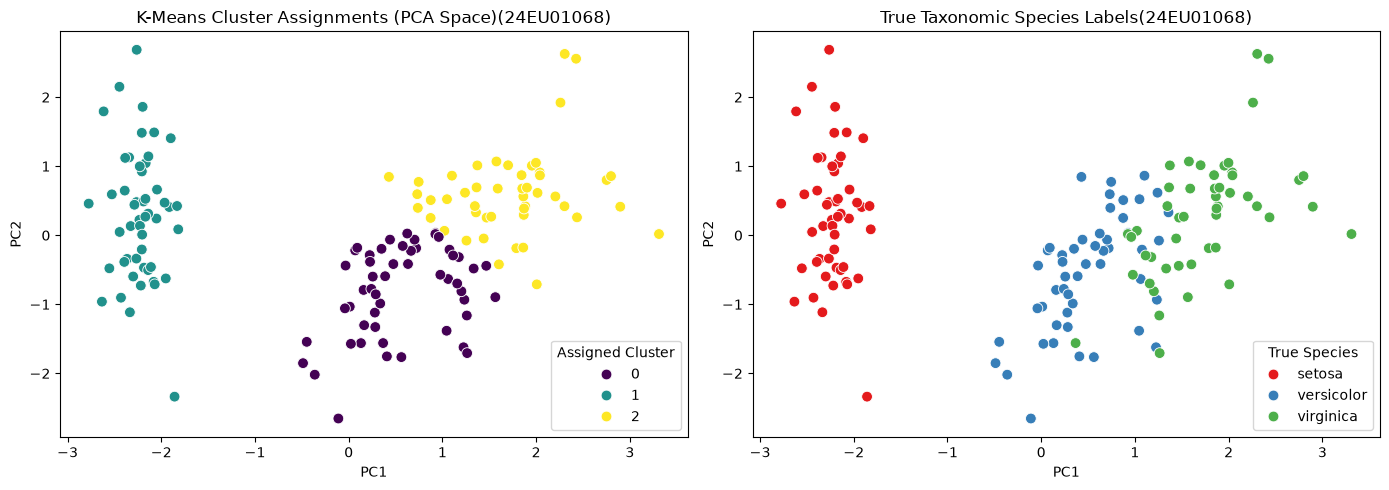

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels, 
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("K-Means Cluster Assignments (PCA Space)(24EU01068)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name', 
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("True Taxonomic Species Labels(24EU01068)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()

### Subtask 3.4: Compiling the Performance Comparison Table
**Concept:** Organize and print your clustering performance metrics in a structured comparison table.


In [40]:
comparison_metrics = pd.DataFrame(
    data=[
        [sil_raw, ch_raw, ari_raw, nmi_raw],
        [sil_pca, ch_pca, ari_pca, nmi_pca]
    ],
    columns=['Silhouette_Score', 'Calinski_Harabasz', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info'],
    index=['Standardized Raw Space (4D)', 'PCA Reduced Space (2D)']
)


In [42]:
print("--- Clustering Performance Summary: Raw vs. PCA ---")
print(comparison_metrics.round(4))

--- Clustering Performance Summary: Raw vs. PCA ---
                             Silhouette_Score  Calinski_Harabasz  \
Standardized Raw Space (4D)            0.4599           241.9044   
PCA Reduced Space (2D)                 0.5092           293.8565   

                             Adjusted_Rand_Index  Normalized_Mutual_Info  
Standardized Raw Space (4D)               0.6201                  0.6595  
PCA Reduced Space (2D)                    0.6201                  0.6595  
